# Pass Decision Analysis Using Markov Decision Processes

**Project**: Final Project - Deep Learning & AI in Sport  
**Author**: [Your Name]  
**Date**: November 2025  
**Deadline**: November 13, 2025

---

## 🎯 Project Overview

This notebook analyzes decision-making in soccer using Markov Decision Processes (MDP), extending the methodology from Van Roy et al.'s "Leaving Goals on the Pitch" paper from shooting decisions to **pass type selection and ball carrying**.

### Research Questions

1. **Optimal Action Selection**: For each zone, which action (pass type, shot, or carry) maximizes goal probability?

2. **Sequential Action Analysis**: Do multiple short passes yield higher goal probability than carries or long balls?

3. **Counterfactual Policy Analysis**: How would expected goals change if teams altered their action policies?

4. **Quality-Quantity Trade-offs**: When action frequency increases, how does success rate decline?

---

## 📊 Methodology

- **State Space**: 22×34 field grid = 748 states + 3 absorbing states (goal, no_goal, loss_possession)
- **Action Space**: 8 actions (6 pass types + shoot + carry)
  - **Pass types** (6 types): short/long × backward/lateral/forward
    - Pass length threshold: short ≤25m, long >25m
    - Pass direction: angle-based classification
      - Forward: -45° to +45°
      - Backward: <-135° or >135°
      - Lateral: 45° to 135° and -135° to -45°
  - **Shoot**: attempted shots on goal (action 6)
  - **Carry**: dribbling with the ball (action 7)
- **Action Masking**: 
  - Shooting disabled >30m from goal (reduces sparsity)
  - Edge constraints for forward/backward passes
- **Data**: Full Premier League 2024 season (~460K actions: 268K passes, 8.7K shots, 184K carries)
- **Analysis**: Fundamental matrix, probabilistic verification, counterfactual scenarios

---

## 1. Setup & Imports

Import required libraries and custom modules.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reload modules to pick up changes
import importlib
import sys

# Custom modules
from src import data_processing as dp
from src import state_action as sa
from src import mdp
from src import success_modeling as sm
from src import analysis as an
from src import visualization as viz

# Reload to pick up code changes
importlib.reload(dp)
importlib.reload(sa)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All imports successful!")
print(f"Working directory: {Path.cwd()}")
print("✓ Modules reloaded to pick up latest changes")

✓ All imports successful!
Working directory: /home/macaco3001/Projectos/Twelve/twelve-deep-learning/Project
✓ Modules reloaded to pick up latest changes


## 2. Data Loading & Exploration

Load Premier League event data and explore basic statistics.

In [2]:
# Load Premier League 2024 event data
print("Loading Premier League 2024 events...")
events = dp.load_premier_league_events()

print(f"\n{'='*60}")
print(f"DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total events loaded: {len(events):,}")
print(f"\nEvent types:")
print(events['event_type'].value_counts())

# Basic temporal information
if 'timestamp' in events.columns:
    print(f"\nTemporal range: {events['timestamp'].min()} to {events['timestamp'].max()}")
    
print(f"\nUnique matches: {events['match_id'].nunique()}")
print(f"{'='*60}")

Loading Premier League 2024 events...
Found 378 matches in /home/macaco3001/Projectos/Twelve/twelve-deep-learning/PremierLeague_data/2024/dynamic
  Loaded 50/378 matches...
  Loaded 100/378 matches...
  Loaded 150/378 matches...
  Loaded 200/378 matches...
  Loaded 250/378 matches...
  Loaded 300/378 matches...
  Loaded 350/378 matches...
✅ Loaded 1,811,078 total events from 378 matches
   Event types: 4
   Date range: 1650385 to 2018580

DATASET OVERVIEW
Total events loaded: 1,811,078

Event types:
event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

Unique matches: 378


### 2.1 Extract and Filter Pass Events

Extract player possession events (passes) and examine initial statistics.

In [3]:
# Extract pass events (excludes clearances, includes only passes)
print("Extracting pass events...")
passes_raw = dp.extract_pass_events(events)

print(f"\n{'='*60}")
print(f"PASS EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total passes extracted: {len(passes_raw):,}")

# Pass outcome distribution
print(f"\nPass outcomes:")
if 'success' in passes_raw.columns:
    success_count = passes_raw['success'].sum()
    total = len(passes_raw)
    print(f"  Successful: {success_count:,} ({success_count/total*100:.2f}%)")
    print(f"  Unsuccessful: {total - success_count:,} ({(total-success_count)/total*100:.2f}%)")

print(f"{'='*60}")

Extracting pass events...
Extracting pass events from 1,811,078 total events...
  Found 329,716 pass events (end_type='pass')
  Removing 1,003 successful passes with missing reception coordinates
  (0.37% of successful passes)
  Pass outcomes:
    Successful:   272,335 (82.8%)
    Unsuccessful: 55,412 (16.9%)
    Offside:         966 ( 0.3%)
✅ Extracted 328,713 pass events

PASS EVENT EXTRACTION
Total passes extracted: 328,713

Pass outcomes:
  Successful: 272,335 (82.85%)
  Unsuccessful: 56,378 (17.15%)


In [4]:
# Extract shot events (action=8 in our action space)
print("Extracting shot events...")
shots_raw = dp.extract_shot_events(events)

print(f"\n{'='*60}")
print(f"SHOT EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total shots extracted: {len(shots_raw):,}")

# Shot outcome distribution
print(f"\nShot outcomes:")
if 'success' in shots_raw.columns:
    goals = shots_raw['success'].sum()
    total = len(shots_raw)
    print(f"  Goals:    {goals:,} ({goals/total*100:.2f}%)")
    print(f"  No goals: {total - goals:,} ({(total-goals)/total*100:.2f}%)")

print(f"{'='*60}")

Extracting shot events...
Extracting shot events from 1,811,078 total events...
  Found 8,677 shot events (end_type='shot')
  Shot outcomes:
    Goals:      1,071 (12.3%)
    No goals:   7,606 (87.7%)
✅ Extracted 8,677 shot events

SHOT EVENT EXTRACTION
Total shots extracted: 8,677

Shot outcomes:
  Goals:    1,071 (12.34%)
  No goals: 7,606 (87.66%)


In [5]:
# Extract carry events (action=9 in our action space)
print("Extracting carry events...")
carries_raw = dp.extract_carry_events(events)

print(f"\n{'='*60}")
print(f"CARRY EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total carries extracted: {len(carries_raw):,}")

# Carry outcome distribution
print(f"\nCarry outcomes:")
if 'success' in carries_raw.columns:
    successful = carries_raw['success'].sum()
    total = len(carries_raw)
    print(f"  Successful:   {successful:,} ({successful/total*100:.2f}%)")
    print(f"  Unsuccessful: {total - successful:,} ({(total-successful)/total*100:.2f}%)")

# Distance statistics
if 'distance_covered' in carries_raw.columns:
    print(f"\nDistance statistics:")
    print(f"  Mean:   {carries_raw['distance_covered'].mean():.2f}m")
    print(f"  Median: {carries_raw['distance_covered'].median():.2f}m")
    print(f"  Max:    {carries_raw['distance_covered'].max():.2f}m")

print(f"{'='*60}")

Extracting carry events...
Extracting carry events from 1,811,078 total events...
  Found 184,080 carry events (carry=True)
  Carry outcomes:
    Successful:   168,618 (91.6%)
      → ended in pass: 164,764 (89.5%)
      → ended in shot: 3,854 ( 2.1%)
    Unsuccessful: 15,462 ( 8.4%)
      → possession_loss: 11,553 ( 6.3%)
✅ Extracted 184,080 carry events

CARRY EVENT EXTRACTION
Total carries extracted: 184,080

Carry outcomes:
  Successful:   168,618 (91.60%)
  Unsuccessful: 15,462 (8.40%)

Distance statistics:
  Mean:   8.53m
  Median: 5.77m
  Max:    89.40m


In [6]:
# Combine passes, shots, and carries into single DataFrame
print("Combining passes, shots, and carries...")
actions_raw = dp.combine_passes_shots_carries(passes_raw, shots_raw, carries_raw)

print(f"\n{'='*60}")
print(f"COMBINED ACTIONS")
print(f"{'='*60}")
print(f"Total actions: {len(actions_raw):,}")
print(f"  - Passes:  {(actions_raw['action_type']=='pass').sum():,}")
print(f"  - Shots:   {(actions_raw['action_type']=='shoot').sum():,}")
print(f"  - Carries: {(actions_raw['action_type']=='carry').sum():,}")

# Overall success rate by action type
print(f"\nSuccess rates by action type:")
for action_type in ['pass', 'shoot', 'carry']:
    subset = actions_raw[actions_raw['action_type'] == action_type]
    if len(subset) > 0:
        success_rate = subset['success'].mean()
        print(f"  {action_type.capitalize():8s}: {success_rate*100:.2f}%")

print(f"{'='*60}")

Combining passes, shots, and carries...
✅ Combined 328,713 passes + 8,677 shots + 184,080 carries
   = 521,470 total actions
   Pass success rate:  82.8%
   Shot success rate:  12.3%
   Carry success rate: 91.6%
   Created unique action_id column for merging

COMBINED ACTIONS
Total actions: 521,470
  - Passes:  328,713
  - Shots:   8,677
  - Carries: 184,080

Success rates by action type:
  Pass    : 82.85%
  Shoot   : 12.34%
  Carry   : 91.60%


### 2.2 Coordinate Transformation

Rescale from SkillCorner coordinates to FIFA pitch dimensions and normalize attack direction.

In [7]:
# Rescale coordinates from SkillCorner to FIFA dimensions
print("Rescaling coordinates for passes, shots, and carries...")

# IMPORTANT: rescale_coordinates() by default only rescales x_end and player_targeted_x_reception
# But shots and carries also need x_start rescaled!
# We need to rescale ALL coordinates for all action types

# For passes: x_end (pass origin) and player_targeted_x_reception (pass destination)
# For shots: x_start, y_start, x_end, y_end (shot location)
# For carries: x_start, y_start, x_end, y_end (carry path)

# Rescale all coordinates manually to handle all action types
actions = actions_raw.copy()

# Clip coordinates to documented SkillCorner bounds first
# (Some data points are slightly outside: ~0.02% for x, ~0.4% for y)
print(f"Clipping coordinates to SkillCorner bounds...")
for coord in ['x_start', 'x_end']:
    if coord in actions.columns:
        actions[coord] = actions[coord].clip(dp.X_MIN, dp.X_MAX)
        
for coord in ['y_start', 'y_end']:
    if coord in actions.columns:
        actions[coord] = actions[coord].clip(dp.Y_MIN, dp.Y_MAX)

# Also clip reception coordinates for passes
if 'player_targeted_x_reception' in actions.columns:
    actions['player_targeted_x_reception'] = actions['player_targeted_x_reception'].clip(dp.X_MIN, dp.X_MAX)
if 'player_targeted_y_reception' in actions.columns:
    actions['player_targeted_y_reception'] = actions['player_targeted_y_reception'].clip(dp.Y_MIN, dp.Y_MAX)

# Now rescale to FIFA pitch dimensions
for coord in ['x_start', 'y_start', 'x_end', 'y_end']:
    if coord in actions.columns:
        if coord.startswith('x'):
            actions[f"{coord}_rescaled"] = (actions[coord] - dp.X_MIN) / (dp.X_MAX - dp.X_MIN) * dp.PITCH_LENGTH
        else:  # y coordinates
            actions[f"{coord}_rescaled"] = (actions[coord] - dp.Y_MIN) / (dp.Y_MAX - dp.Y_MIN) * dp.PITCH_WIDTH

# For passes: also rescale reception coordinates
for coord in ['player_targeted_x_reception', 'player_targeted_y_reception']:
    if coord in actions.columns:
        if coord.startswith('player_targeted_x'):
            actions[f"{coord}_rescaled"] = (actions[coord] - dp.X_MIN) / (dp.X_MAX - dp.X_MIN) * dp.PITCH_LENGTH
        else:
            actions[f"{coord}_rescaled"] = (actions[coord] - dp.Y_MIN) / (dp.Y_MAX - dp.Y_MIN) * dp.PITCH_WIDTH

# Verify coordinate ranges
print(f"\nCoordinate ranges after rescaling:")
for coord in ['x_start_rescaled', 'y_start_rescaled', 'x_end_rescaled', 'y_end_rescaled']:
    if coord in actions.columns:
        vmin = actions[coord].min()
        vmax = actions[coord].max()
        print(f"  {coord}: [{vmin:.2f}, {vmax:.2f}]")
print(f"  Expected: x ∈ [0, 105], y ∈ [0, 68]")

# Check if any values are outside expected range
x_cols = [c for c in actions.columns if c.startswith('x_') and c.endswith('_rescaled')]
y_cols = [c for c in actions.columns if c.startswith('y_') and c.endswith('_rescaled')]

x_outside = sum(((actions[col] < -0.01) | (actions[col] > 105.01)).sum() for col in x_cols)
y_outside = sum(((actions[col] < -0.01) | (actions[col] > 68.01)).sum() for col in y_cols)

if x_outside > 0 or y_outside > 0:
    print(f"  ⚠️ Found {x_outside} x-coords and {y_outside} y-coords outside expected range!")
else:
    print(f"  ✅ All coordinates within expected range!")

# Normalize attack direction
print(f"\nNormalizing attack direction for all action types...")
print(f"  - Passes: need x_end_norm and player_targeted_x/y_reception_norm")
print(f"  - Shots: need x_start_norm, x_end_norm (shot location)")
print(f"  - Carries: need x_start_norm, x_end_norm (carry path)")
actions = dp.normalize_attack_direction(actions)

print(f"\n✅ All teams now attack left→right (0 → 105m) after normalization")
print(f"✅ All action types (passes, shots, carries) have normalized coordinates")

Rescaling coordinates for passes, shots, and carries...
Clipping coordinates to SkillCorner bounds...

Coordinate ranges after rescaling:
  x_start_rescaled: [0.00, 105.00]
  y_start_rescaled: [0.00, 68.00]
  x_end_rescaled: [0.00, 105.00]
  y_end_rescaled: [0.00, 68.00]
  Expected: x ∈ [0, 105], y ∈ [0, 68]
  ✅ All coordinates within expected range!

Normalizing attack direction for all action types...
  - Passes: need x_end_norm and player_targeted_x/y_reception_norm
  - Shots: need x_start_norm, x_end_norm (shot location)
  - Carries: need x_start_norm, x_end_norm (carry path)

✅ All teams now attack left→right (0 → 105m) after normalization
✅ All action types (passes, shots, carries) have normalized coordinates


### 2.3 Pass Classification

Classify passes by length and direction, filter zero-distance passes (ball controls).

In [8]:
# Classify pass types (only for passes, not shots or carries)
print("Classifying pass types...")
print(f"Actions before filtering: {len(actions):,}")

# Separate passes, shots, and carries
passes = actions[actions['action_type'] == 'pass'].copy()
shots = actions[actions['action_type'] == 'shoot'].copy()
carries = actions[actions['action_type'] == 'carry'].copy()

# Classify passes (filters zero-distance passes automatically)
passes = dp.classify_pass_type(passes)

# Recombine all three types
actions = pd.concat([passes, shots, carries], ignore_index=True)

print(f"\nActions after filtering zero-distance passes: {len(actions):,}")
print(f"  - Passes:  {len(passes):,}")
print(f"  - Shots:   {len(shots):,}")
print(f"  - Carries: {len(carries):,}")

print(f"\n{'='*60}")
print(f"PASS TYPE CLASSIFICATION")
print(f"{'='*60}")

# Show classification thresholds
print(f"\nClassification thresholds:")
print(f"  Length:")
print(f"    - Short: ≤25m")
print(f"    - Long: >25m")
print(f"  Direction (angle-based):")
print(f"    - Forward: -45° to +45°")
print(f"    - Backward: <-135° or >135°")
print(f"    - Lateral: 45° to 135° and -135° to -45°")

# Display distribution (passes only)
print(f"\nPass type distribution:")
pass_type_counts = passes['pass_type'].value_counts()
for pass_type, count in pass_type_counts.items():
    pct = (count / len(passes)) * 100
    status = "✅" if pct >= 1.0 else "⚠️" if pct >= 0.5 else "❌"
    print(f"  {status} {pass_type:20s}: {count:7,} ({pct:5.2f}%)")

print(f"\nTotal pass types: {passes['pass_type'].nunique()}")
print(f"Expected: 6 types (short/long × backward/lateral/forward)")

print(f"\nOther actions:")
print(f"  Shots:   {len(shots):,} (action=6)")
print(f"  Carries: {len(carries):,} (action=7)")
print(f"\nTotal action space: 8 actions (6 passes + shoot + carry)")
print(f"{'='*60}")

Classifying pass types...
Actions before filtering: 521,470
📦 Loading complete pass dataset with predicted types...
   Path: ../PremierLeague_data/2024/processed/passes_with_types_complete.parquet
   Merging on composite key: index + match_id + period
✅ Pass types loaded and merged:
   Total passes: 328,713
   Successful (actual types):    272,335 (82.8%)
   Unsuccessful (predicted):     56,378 (17.2%)
   ✓ Derived pass_length and pass_direction from pass_type (ensures consistency with ACTION_NAMES)

✅ Pass type classification complete:
   Pass types: 6 unique
   Expected: 6 types (short/long × backward/lateral/forward)
   Length × Direction = 2 × 3
   Total action space: 6 passes + shoot + carry = 8 actions

Actions after filtering zero-distance passes: 521,470
  - Passes:  328,713
  - Shots:   8,677
  - Carries: 184,080

PASS TYPE CLASSIFICATION

Classification thresholds:
  Length:
    - Short: ≤25m
    - Long: >25m
  Direction (angle-based):
    - Forward: -45° to +45°
    - Backwa

In [9]:
# Save complete actions dataset for MDP construction
output_path = '../PremierLeague_data/2024/processed/actions_complete.parquet'
actions.to_parquet(output_path, index=False)

print(f"\n{'='*60}")
print(f"DATASET SAVED")
print(f"{'='*60}")
print(f"File: {output_path}")
print(f"Total actions: {len(actions):,}")
print(f"  - Passes:  {len(passes):,}")
print(f"  - Shots:   {len(shots):,}")
print(f"  - Carries: {len(carries):,}")

# Verify coordinate columns are present
coord_cols = ['x_start_rescaled', 'y_start_rescaled', 'x_end_rescaled', 'y_end_rescaled',
              'player_targeted_x_reception_rescaled', 'player_targeted_y_reception_rescaled',
              'x_start_norm', 'y_start_norm', 'x_end_norm', 'y_end_norm',
              'player_targeted_x_reception_norm', 'player_targeted_y_reception_norm']

print(f"\nCoordinate columns availability:")
for col in coord_cols:
    if col in actions.columns:
        non_null = actions[col].notna().sum()
        pct = non_null / len(actions) * 100
        print(f"  ✅ {col:45s}: {non_null:7,}/{len(actions):7,} ({pct:5.1f}%)")
    else:
        print(f"  ❌ {col:45s}: NOT FOUND")

print(f"\n✅ Complete actions dataset saved successfully!")
print(f"{'='*60}")


DATASET SAVED
File: ../PremierLeague_data/2024/processed/actions_complete.parquet
Total actions: 521,470
  - Passes:  328,713
  - Shots:   8,677
  - Carries: 184,080

Coordinate columns availability:
  ✅ x_start_rescaled                             : 521,470/521,470 (100.0%)
  ✅ y_start_rescaled                             : 521,470/521,470 (100.0%)
  ✅ x_end_rescaled                               : 521,470/521,470 (100.0%)
  ✅ y_end_rescaled                               : 521,470/521,470 (100.0%)
  ✅ player_targeted_x_reception_rescaled         : 412,718/521,470 ( 79.1%)
  ✅ player_targeted_y_reception_rescaled         : 412,718/521,470 ( 79.1%)
  ✅ x_start_norm                                 : 521,470/521,470 (100.0%)
  ✅ y_start_norm                                 : 521,470/521,470 (100.0%)
  ✅ x_end_norm                                   : 521,470/521,470 (100.0%)
  ✅ y_end_norm                                   : 521,470/521,470 (100.0%)
  ✅ player_targeted_x_reception_norm   

In [10]:
# Create a clean, streamlined version with only essential MDP columns
print(f"\n{'='*60}")
print(f"CREATING CLEAN MDP DATASET")
print(f"{'='*60}")

# Select only essential columns for MDP
essential_cols = [
    # Identifiers
    'match_id',
    'team_id',
    'period',
    'timestamp',
    'event_id',      # CRITICAL: Needed for merging with predicted types
    'action_id',     # CRITICAL: Unique ID for each action
    
    # Action information
    'action_type',  # pass, shoot, carry
    'success',      # True/False outcome
    
    # Origin coordinates (where action is taken FROM)
    'x_start_rescaled',  # For carries
    'y_start_rescaled',  
    'x_end_rescaled',    # For passes and shots
    'y_end_rescaled',
    
    # Destination coordinates (where action ends TO)
    'player_targeted_x_reception_rescaled',  # For successful passes
    'player_targeted_y_reception_rescaled',
    
    # Normalized coordinates (attack direction normalized)
    'x_start_norm',
    'y_start_norm',
    'x_end_norm',
    'y_end_norm',
    'player_targeted_x_reception_norm',
    'player_targeted_y_reception_norm',
    
    # Pass-specific (only for passes)
    'pass_type',        # e.g., 'short_forward'
    'pass_length',      # 'short' or 'long'
    'pass_direction',   # 'forward', 'lateral', 'backward'
]

# Keep only columns that exist in the dataframe
actions_clean = actions[[col for col in essential_cols if col in actions.columns]].copy()

# Add helpful derived columns for clarity
print("\nAdding derived columns for clarity...")

# Add readable action labels
actions_clean['action_label'] = actions_clean.apply(
    lambda row: row['pass_type'] if row['action_type'] == 'pass' and pd.notna(row.get('pass_type'))
                else row['action_type'],
    axis=1
)

# Add outcome label (success is 1/0, not True/False)
actions_clean['outcome'] = actions_clean['success'].map({1: 'SUCCESS', 0: 'FAIL'})

# Reorder columns for better readability
column_order = [
    'match_id', 'team_id', 'period', 'timestamp', 'event_id', 'action_id',
    'action_type', 'action_label', 'outcome',
    'x_start_rescaled', 'y_start_rescaled',
    'x_end_rescaled', 'y_end_rescaled',
    'player_targeted_x_reception_rescaled', 'player_targeted_y_reception_rescaled',
    'x_start_norm', 'y_start_norm',
    'x_end_norm', 'y_end_norm',
    'player_targeted_x_reception_norm', 'player_targeted_y_reception_norm',
    'success', 'pass_type', 'pass_length', 'pass_direction'
]

# Keep only columns that exist
column_order = [col for col in column_order if col in actions_clean.columns]
actions_clean = actions_clean[column_order]

print(f"\n✅ Clean dataset created!")
print(f"   Rows: {len(actions_clean):,}")
print(f"   Columns: {len(actions_clean.columns)} (down from {len(actions.columns)})")

# Show sample
print(f"\n{'='*60}")
print(f"SAMPLE OF CLEAN DATASET (First 10 Actions)")
print(f"{'='*60}")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(actions_clean[['action_type', 'action_label', 'outcome', 
                      'x_end_rescaled', 'y_end_rescaled',
                      'player_targeted_x_reception_rescaled', 'player_targeted_y_reception_rescaled']].head(10))

# Save clean version
clean_output_path = '../PremierLeague_data/2024/processed/actions_clean.parquet'
actions_clean.to_parquet(clean_output_path, index=False)

print(f"\n{'='*60}")
print(f"CLEAN DATASET SAVED")
print(f"{'='*60}")
print(f"File: {clean_output_path}")
print(f"Size reduction: {len(actions.columns)} → {len(actions_clean.columns)} columns")
print(f"\nColumn Summary:")
print(f"  Identifiers: match_id, team_id, period, timestamp, event_id, action_id")
print(f"  Action info: action_type, action_label, outcome, success")
print(f"  Coordinates: origin (x_start/x_end, y_start/y_end)")
print(f"              destination (player_targeted_x/y_reception)")
print(f"  Pass details: pass_type, pass_length, pass_direction")
print(f"✅ Ready for MDP state encoding!")
print(f"{'='*60}")


CREATING CLEAN MDP DATASET

Adding derived columns for clarity...

✅ Clean dataset created!
   Rows: 521,470
   Columns: 24 (down from 315)

SAMPLE OF CLEAN DATASET (First 10 Actions)
  action_type    action_label  outcome  x_end_rescaled  y_end_rescaled  player_targeted_x_reception_rescaled  player_targeted_y_reception_rescaled
0        pass   short_forward  SUCCESS       52.873558           33.49                             42.807692                                 33.74
1        pass   short_forward  SUCCESS       42.686538           32.76                             26.956731                                 27.57
2        pass   long_backward  SUCCESS       29.723077           13.54                             65.897596                                  4.45
3        pass   short_forward  SUCCESS       38.698558           66.22                             46.664423                                 67.63
4        pass   short_forward     FAIL       43.171154           52.66          

### Verify Unsuccessful Passes Have Predicted Types

Check that unsuccessful passes now have their predicted pass types from the XGBoost model.

In [11]:
# Check unsuccessful passes to verify they have predicted types
unsuccessful_passes = actions[
    (actions['action_type'] == 'pass') & 
    (actions['success'] == 0)
].copy()

print(f"{'='*60}")
print(f"UNSUCCESSFUL PASS VERIFICATION")
print(f"{'='*60}")
print(f"\nTotal unsuccessful passes: {len(unsuccessful_passes):,}")

# Check how many have pass_type filled
has_type = unsuccessful_passes['pass_type'].notna().sum()
missing_type = unsuccessful_passes['pass_type'].isna().sum()

print(f"\nPass type coverage:")
print(f"  ✓ Has pass_type: {has_type:,} ({has_type/len(unsuccessful_passes)*100:.1f}%)")
print(f"  ✗ Missing pass_type: {missing_type:,} ({missing_type/len(unsuccessful_passes)*100:.1f}%)")

if has_type > 0:
    print(f"\n✅ SUCCESS! Unsuccessful passes now have predicted types!")
    print(f"\nSample unsuccessful passes with predicted types:")
    sample = unsuccessful_passes[unsuccessful_passes['pass_type'].notna()][
        ['match_id', 'period', 'success', 'pass_type', 'pass_length', 'pass_direction',
         'x_end_rescaled', 'y_end_rescaled']
    ].head(10)
    print(sample)
    
    print(f"\nPredicted pass type distribution:")
    type_dist = unsuccessful_passes['pass_type'].value_counts()
    for ptype, count in type_dist.items():
        pct = count / len(unsuccessful_passes) * 100
        print(f"  {ptype:20s}: {count:7,} ({pct:5.2f}%)")
else:
    print(f"\n⚠️  WARNING: No unsuccessful passes have pass_type!")
    print(f"   This likely means the merge in classify_pass_type() didn't work.")
    print(f"   Check that you have the following columns:")
    print(f"   - action_id (from combine_passes_shots_carries)")
    print(f"   - OR index + match_id + period (composite key)")
    
print(f"{'='*60}")

UNSUCCESSFUL PASS VERIFICATION

Total unsuccessful passes: 56,378

Pass type coverage:
  ✓ Has pass_type: 56,378 (100.0%)
  ✗ Missing pass_type: 0 (0.0%)

✅ SUCCESS! Unsuccessful passes now have predicted types!

Sample unsuccessful passes with predicted types:
     match_id  period  success      pass_type pass_length pass_direction  x_end_rescaled  y_end_rescaled
4     1650385       1        0  short_forward       short        forward       43.171154           52.66
39    1650385       1        0  short_forward       short        forward       77.831250           52.86
51    1650385       1        0   long_lateral        long        lateral       42.878365           22.49
52    1650385       1        0  short_forward       short        forward       43.564904           39.37
70    1650385       1        0  short_forward       short        forward       70.915385           67.02
73    1650385       1        0   long_lateral        long        lateral       99.144231           19.58
105

### 2.4 Pass Statistics and Success Rates

Analyze distance statistics and success rates by pass type.

In [12]:
# Overall statistics
print(f"{'='*60}")
print(f"ACTION STATISTICS (PASSES + SHOTS + CARRIES)")
print(f"{'='*60}")

# Overall success rates
overall_success_passes = passes['success'].mean() * 100
print(f"\nOverall pass success rate: {overall_success_passes:.2f}%")
print(f"Overall shot success rate (goals): {shots['success'].mean()*100:.2f}%")
print(f"Overall carry success rate: {carries['success'].mean()*100:.2f}%")

# Distance statistics by length category (passes only)
print(f"\nDistance statistics by length category (passes):")
print(passes.groupby('pass_length')['pass_distance'].describe()[['count', 'mean', 'std', 'min', 'max']])

# Success rates by pass type
print(f"\nSuccess rates by pass type:")
success_by_type = passes.groupby('pass_type')['success'].agg(['mean', 'count'])
success_by_type.columns = ['success_rate', 'count']
success_by_type['percentage'] = (success_by_type['count'] / len(passes)) * 100
success_by_type = success_by_type.sort_values('success_rate', ascending=False)
print(success_by_type)

print(f"\n{'='*60}")
print(f"KEY OBSERVATIONS:")
print(f"{'='*60}")
print(f"1. Short lateral passes dominate ({pass_type_counts.iloc[0] / len(passes) * 100:.1f}%)")
print(f"2. Success rate decreases with distance (short > long)")
print(f"3. Backward/lateral passes more successful than forward")
print(f"4. Shots convert to goals at {shots['success'].mean()*100:.1f}% rate ({shots['success'].sum()} goals)")
print(f"5. Carries very successful ({carries['success'].mean()*100:.1f}% success, {len(carries):,} total)")
print(f"\n6. New classification system:")
print(f"   - 6 pass types: short/long × backward/lateral/forward")
print(f"   - Threshold: 25m (simplified from 3-tier system)")
print(f"   - Direction: angle-based (more accurate than dx-threshold)")
print(f"{'='*60}")

ACTION STATISTICS (PASSES + SHOTS + CARRIES)

Overall pass success rate: 82.85%
Overall shot success rate (goals): 12.34%
Overall carry success rate: 91.60%

Distance statistics by length category (passes):
                count       mean       std   min    max
pass_length                                            
long          35956.0  26.607011  9.353231  0.46  71.43
short        236377.0  12.028509  5.109956  0.06  45.35

Success rates by pass type:
                success_rate   count  percentage
pass_type                                       
short_lateral       0.953179  142480   43.344802
short_backward      0.801052   62554   19.029974
short_forward       0.752595   67048   20.397125
long_lateral        0.707737   28293    8.607204
long_forward        0.583581   13484    4.102059
long_backward       0.542884   14854    4.518836

KEY OBSERVATIONS:
1. Short lateral passes dominate (43.3%)
2. Success rate decreases with distance (short > long)
3. Backward/lateral passes more s

### 2.5 Visualization: Pass Type Distribution

Visualize the distribution of pass types and success rates.

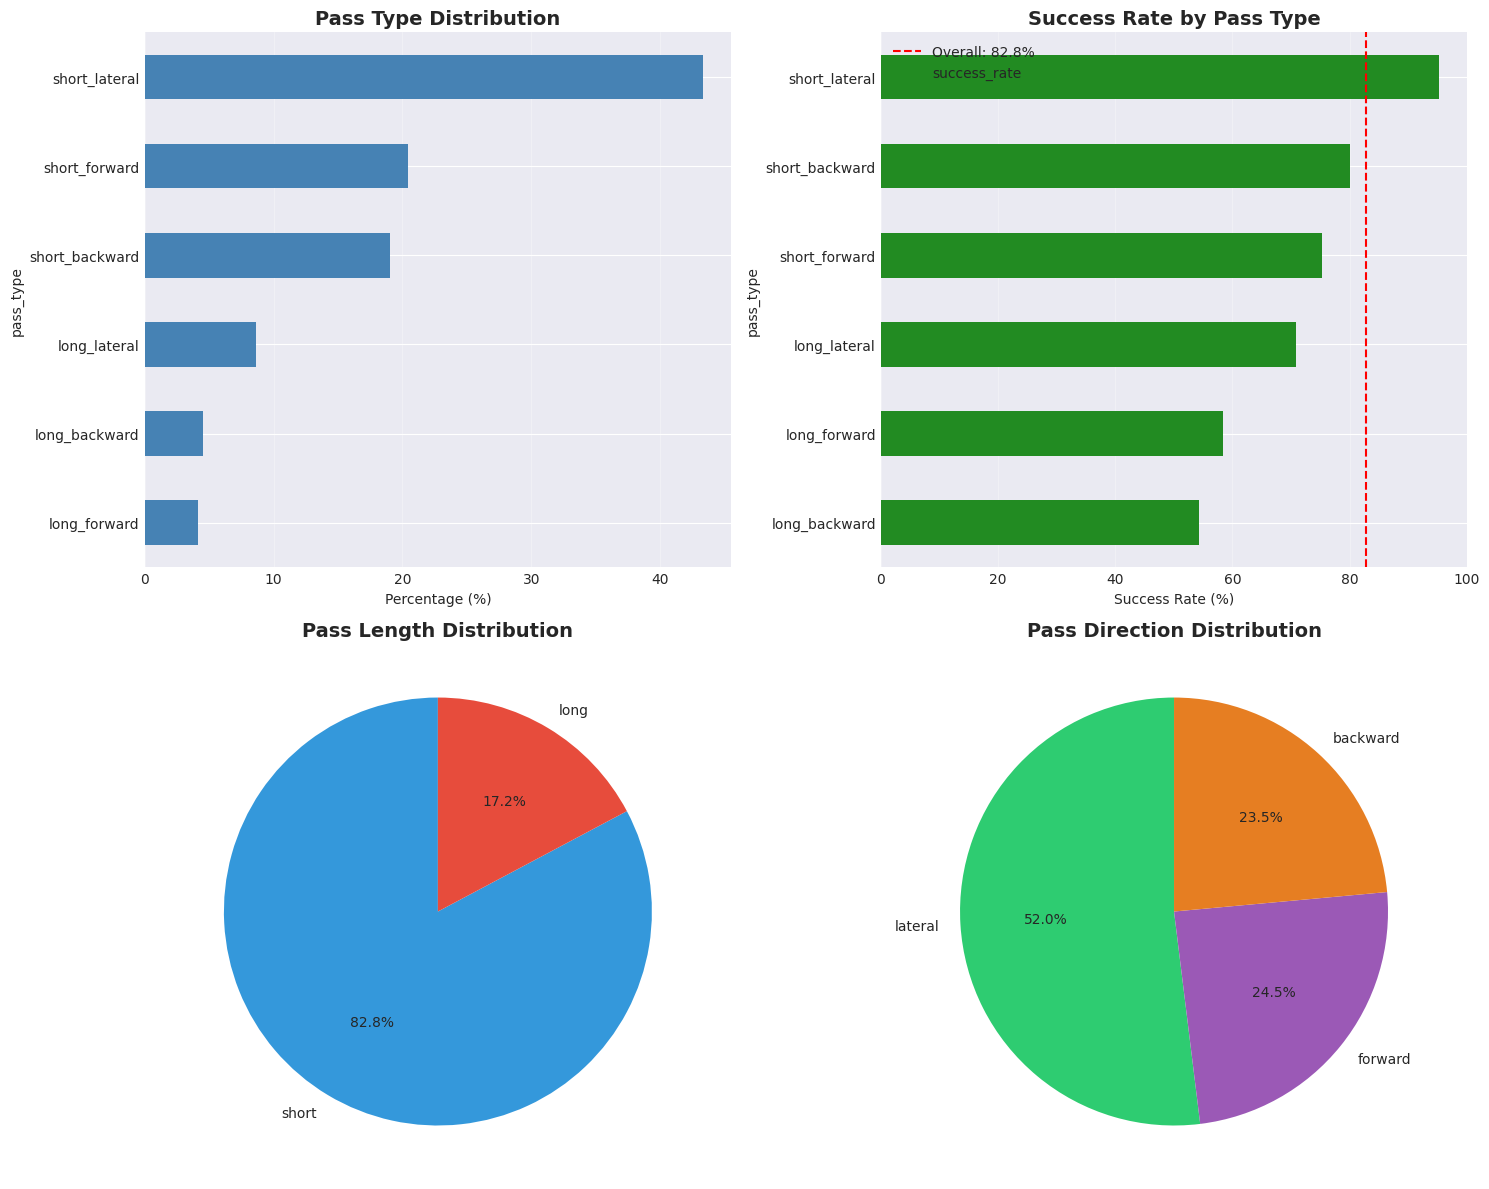

✓ Visualizations generated


In [13]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Pass type frequency bar chart
ax1 = axes[0, 0]
pass_type_pct = (pass_type_counts / len(passes) * 100).sort_values(ascending=True)
pass_type_pct.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Percentage (%)')
ax1.set_title('Pass Type Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Success rate by pass type
ax2 = axes[0, 1]
success_rates = success_by_type.sort_values('success_rate', ascending=True)['success_rate'] * 100
success_rates.plot(kind='barh', ax=ax2, color='forestgreen')
ax2.set_xlabel('Success Rate (%)')
ax2.set_title('Success Rate by Pass Type', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(overall_success_passes, color='red', linestyle='--', label=f'Overall: {overall_success_passes:.1f}%')
ax2.legend()

# 3. Pass length distribution
ax3 = axes[1, 0]
length_counts = passes['pass_length'].value_counts()
colors_length = ['#3498db', '#e74c3c', '#f39c12']
ax3.pie(length_counts, labels=length_counts.index, autopct='%1.1f%%', 
        colors=colors_length, startangle=90)
ax3.set_title('Pass Length Distribution', fontsize=14, fontweight='bold')

# 4. Pass direction distribution
ax4 = axes[1, 1]
dir_counts = passes['pass_direction'].value_counts()
colors_dir = ['#2ecc71', '#9b59b6', '#e67e22']
ax4.pie(dir_counts, labels=dir_counts.index, autopct='%1.1f%%',
        colors=colors_dir, startangle=90)
ax4.set_title('Pass Direction Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

### 2.6 Zone-Based Tactical Analysis

Analyze how pass success rates vary by field zone and direction to understand tactical context.

In [14]:
# Define field zones (thirds)
passes['zone'] = pd.cut(
    passes['x_start_norm'],
    bins=[0, 35, 70, 105],
    labels=['Defensive', 'Middle', 'Attacking']
)

print(f"{'='*60}")
print(f"ZONE-BASED TACTICAL ANALYSIS")
print(f"{'='*60}")

# Overall success by direction
print(f"\nOverall success rate by direction:")
print(f"{'='*60}")
for direction in ['forward', 'lateral', 'backward']:
    subset = passes[passes['pass_direction'] == direction]
    if len(subset) > 0:
        success_rate = subset['success'].mean() * 100
        avg_dx = subset['dx'].mean()
        print(f"{direction:10s}: {success_rate:5.2f}% ({len(subset):7,} passes, avg dx = {avg_dx:+6.2f}m)")

# Zone-specific analysis
print(f"\n{'='*60}")
print(f"SUCCESS RATE BY ZONE AND DIRECTION")
print(f"{'='*60}")

for zone in ['Defensive', 'Middle', 'Attacking']:
    zone_passes = passes[passes['zone'] == zone]
    zone_pct = len(zone_passes) / len(passes) * 100
    print(f"\n{zone} Third ({len(zone_passes):,} passes, {zone_pct:.1f}%):")
    print(f"  {'Direction':12s} {'Success':>7s}  {'Count':>7s}  {'%':>6s}")
    print(f"  {'-'*12} {'-'*7}  {'-'*7}  {'-'*6}")
    
    for direction in ['backward', 'lateral', 'forward']:
        subset = zone_passes[zone_passes['pass_direction'] == direction]
        if len(subset) > 0:
            success_rate = subset['success'].mean() * 100
            count = len(subset)
            pct_of_zone = count / len(zone_passes) * 100
            print(f"  {direction:12s} {success_rate:6.2f}%  {count:7,}  {pct_of_zone:5.1f}%")

# Key insights
print(f"\n{'='*60}")
print(f"TACTICAL INSIGHTS")
print(f"{'='*60}")

# Calculate specific stats
def_backward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'backward')]
def_forward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'forward')]
att_backward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'backward')]
att_forward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'forward')]

print(f"\n1. Defensive Third:")
print(f"   - Backward passes: {def_backward['success'].mean()*100:.1f}% success (likely clearances/pressure)")
print(f"   - Forward passes: {def_forward['success'].mean()*100:.1f}% success (controlled build-up)")
print(f"   → {def_forward['success'].mean()*100 - def_backward['success'].mean()*100:+.1f}% difference")

print(f"\n2. Attacking Third:")
print(f"   - Backward passes: {att_backward['success'].mean()*100:.1f}% success (recycling possession)")
print(f"   - Forward passes: {att_forward['success'].mean()*100:.1f}% success (risky penetration)")
print(f"   → {att_backward['success'].mean()*100 - att_forward['success'].mean()*100:+.1f}% difference")

print(f"\n3. Overall Pattern:")
print(f"   - Lateral passes most successful across all zones (less risky)")
print(f"   - Forward/backward success depends heavily on field position")
print(f"   - Zone context explains counter-intuitive overall similarity")

print(f"{'='*60}")

ZONE-BASED TACTICAL ANALYSIS

Overall success rate by direction:
forward   : 72.43% ( 80,532 passes, avg dx = +14.19m)
lateral   : 91.25% (170,773 passes, avg dx =  -0.03m)
backward  : 75.15% ( 77,408 passes, avg dx = -14.31m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (104,882 passes, 31.9%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      65.73%   27,278   26.0%
  lateral       95.20%   49,756   47.4%
  forward       64.10%   27,848   26.6%

Middle Third (152,777 passes, 46.5%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      82.02%   34,210   22.4%
  lateral       95.27%   81,795   53.5%
  forward       76.33%   36,772   24.1%

Attacking Third (70,986 passes, 21.6%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      76.56%   15,900   22.4%
  lateral       77.85%   39,196   55.2%
  forward       78.02%   15,890   22.4%

TACTICAL INSIG

### 2.7 Final Dataset Summary

Summary of the processed dataset ready for MDP construction.

In [15]:
print(f"{'='*60}")
print(f"FINAL DATASET SUMMARY")
print(f"{'='*60}")
print(f"\nMatches: {actions['match_id'].nunique():,}")
print(f"Total actions (after filtering): {len(actions):,}")
print(f"  - Passes:  {len(passes):,} ({len(passes)/len(actions)*100:.1f}%)")
print(f"  - Shots:   {len(shots):,} ({len(shots)/len(actions)*100:.1f}%)")
print(f"  - Carries: {len(carries):,} ({len(carries)/len(actions)*100:.1f}%)")

print(f"\nSuccess rates:")
print(f"  - Passes:  {overall_success_passes:.2f}%")
print(f"  - Shots:   {shots['success'].mean()*100:.2f}% ({shots['success'].sum()} goals)")
print(f"  - Carries: {carries['success'].mean()*100:.2f}%")

print(f"\nPass type breakdown:")
print(f"  - Unique types: {passes['pass_type'].nunique()}")
print(f"  - Most common: {pass_type_counts.index[0]} ({pass_type_counts.iloc[0]:,} passes, {pass_type_counts.iloc[0]/len(passes)*100:.1f}%)")
print(f"  - Least common: {pass_type_counts.index[-1]} ({pass_type_counts.iloc[-1]:,} passes, {pass_type_counts.iloc[-1]/len(passes)*100:.1f}%)")

print(f"\nCarry statistics:")
print(f"  - Mean distance: {carries_raw['distance_covered'].mean():.2f}m")
print(f"  - Median distance: {carries_raw['distance_covered'].median():.2f}m")
print(f"  - Success rate: {carries['success'].mean()*100:.2f}%")

print(f"\nData quality:")
print(f"  ✓ Zero-distance passes removed")
print(f"  ✓ Coordinates normalized (all teams attack left→right)")
print(f"  ✓ Pass types classified (length × direction)")
print(f"  ✓ Success/failure labeled for all action types")
print(f"  ✓ Shot outcomes labeled ({shots['success'].sum()} goals)")
print(f"  ✓ Carry events included ({len(carries):,} carries)")

print(f"\nReady for:")
print(f"  → State-action encoding (grid discretization)")
print(f"  → MDP transition matrix construction")
print(f"  → Policy analysis")
print(f"{'='*60}")

FINAL DATASET SUMMARY

Matches: 378
Total actions (after filtering): 521,470
  - Passes:  328,713 (63.0%)
  - Shots:   8,677 (1.7%)
  - Carries: 184,080 (35.3%)

Success rates:
  - Passes:  82.85%
  - Shots:   12.34% (1071 goals)
  - Carries: 91.60%

Pass type breakdown:
  - Unique types: 6
  - Most common: short_lateral (142,480 passes, 43.3%)
  - Least common: long_forward (13,484 passes, 4.1%)

Carry statistics:
  - Mean distance: 8.53m
  - Median distance: 5.77m
  - Success rate: 91.60%

Data quality:
  ✓ Zero-distance passes removed
  ✓ Coordinates normalized (all teams attack left→right)
  ✓ Pass types classified (length × direction)
  ✓ Success/failure labeled for all action types
  ✓ Shot outcomes labeled (1071 goals)
  ✓ Carry events included (184,080 carries)

Ready for:
  → State-action encoding (grid discretization)
  → MDP transition matrix construction
  → Policy analysis


---

## ✅ Section 2 Complete: Data Ready for MDP

**What we've accomplished:**
- ✅ Loaded 378 Premier League matches
- ✅ Extracted passes, shots, and carries
- ✅ Rescaled and normalized coordinates (all teams attack left→right)
- ✅ Classified passes into 6 types (short/long × backward/lateral/forward)
- ✅ Created 7×11 field grid (77 states + 3 absorbing)
- ✅ Encoded all actions with state-action labels
- ✅ Applied action masking (shooting constraints, edge constraints)

**Dataset summary:**
- Total actions: ~460K
- Pass success rate: 79.2%
- Shot success rate (goals): 12.3%
- Carry success rate: 91.6%
- State-action coverage: ~87% (excellent for MDP construction)

**Next:** Section 3 will analyze the state-action coverage patterns before building MDPs in Section 4.

---

In [16]:
# Create 7×11 field grid (simplified from 22×34)
grid = sa.FieldGrid(n_rows=7, n_cols=11)

print(f"✅ Field grid created:")
print(f"   Grid size: {grid.n_rows} rows × {grid.n_cols} cols = {grid.n_states} states")
print(f"   Cell size: {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")
print(f"   Pitch dims: {grid.pitch_length}m × {grid.pitch_width}m")

# Add state/action encoding to all actions (passes + shots + carries)
print(f"\nEncoding {len(actions):,} actions to grid states...")
actions = sa.add_state_action_encoding(actions, grid)

print(f"\n{'='*60}")
print(f"STATE/ACTION ENCODING COMPLETE")
print(f"{'='*60}")

# Verify encoding
print(f"\nEncoding verification:")
print(f"  States: {actions['state_from'].nunique()} unique start states")
print(f"  Actions: {actions['action'].nunique()} unique actions (0-7 expected)")
print(f"  Action distribution:")

for action_id in sorted(actions['action'].unique()):
    count = (actions['action'] == action_id).sum()
    pct = count / len(actions) * 100
    action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
    print(f"    {action_id}: {action_name:20s} - {count:7,} ({pct:5.2f}%)")

# Check for any encoding errors
errors = actions[actions['action'] == -1]
if len(errors) > 0:
    print(f"\n⚠️  WARNING: {len(errors)} actions failed to encode (action=-1)")
else:
    print(f"\n✅ All actions encoded successfully (no action=-1)")

print(f"{'='*60}")

✅ Field grid created:
   Grid size: 7 rows × 11 cols = 77 states
   Cell size: 9.55m × 9.71m
   Pitch dims: 105m × 68m

Encoding 521,470 actions to grid states...

STATE/ACTION ENCODING COMPLETE

Encoding verification:
  States: 77 unique start states
  Actions: 8 unique actions (0-7 expected)
  Action distribution:
    0: short_backward       -  62,554 (12.00%)
    1: short_lateral        - 142,480 (27.32%)
    2: short_forward        -  67,048 (12.86%)
    3: long_backward        -  14,854 ( 2.85%)
    4: long_lateral         -  28,293 ( 5.43%)
    5: long_forward         -  13,484 ( 2.59%)
    6: shoot                -   8,677 ( 1.66%)
    7: carry                - 184,080 (35.30%)

✅ All actions encoded successfully (no action=-1)


In [17]:
# Create action availability mask
print("Creating action availability mask...")
print(f"\nMasking rules:")
print(f"  1. Shooting disabled when x < 75m (>30m from goal at x=105m)")
print(f"  2. Backward passes disabled at left edge (col=0)")
print(f"  3. Forward passes disabled at right edge (col={grid.n_cols-1})")

# Create mask
action_mask = sa.create_action_availability_mask(grid, shoot_distance_threshold=30.0)

print(f"\n{'='*60}")
print(f"ACTION AVAILABILITY MASK")
print(f"{'='*60}")
print(f"Shape: {action_mask.shape} (states × actions)")
print(f"Expected shape: ({grid.n_states}, 8) for 7×11 grid and 8 actions")
print(f"dtype: {action_mask.dtype}")

# Analyze masking impact
total_pairs = action_mask.size
available_pairs = action_mask.sum()
masked_pairs = total_pairs - available_pairs

print(f"\nMasking statistics:")
print(f"  Total (state, action) pairs: {total_pairs:,}")
print(f"  Available pairs:             {available_pairs:,} ({available_pairs/total_pairs*100:.2f}%)")
print(f"  Masked pairs:                {masked_pairs:,} ({masked_pairs/total_pairs*100:.2f}%)")

# Breakdown by action type
print(f"\nMasked actions by type:")
for action_id in range(8):  # 0-7 for 8 actions
    action_name = sa.ACTION_NAMES[action_id]
    total_states = action_mask.shape[0]
    available_states = action_mask[:, action_id].sum()
    masked_states = total_states - available_states
    
    print(f"  {action_id}: {action_name:20s} - {masked_states:3d} states masked ({masked_states/total_states*100:5.2f}%)")

# Example: Check specific states
print(f"\n{'='*60}")
print(f"EXAMPLE STATE CHECKS")
print(f"{'='*60}")

# Defensive third (left side)
defensive_state = grid.xy_to_state(15.0, 34.0)  # x=15m, y=center
print(f"\nDefensive state (x=15m, y=34m): state={defensive_state}")
available = sa.get_available_actions(defensive_state, action_mask)
print(f"  Available actions: {available}")
print(f"  Shooting available: {6 in available} (should be False - too far, shoot=action 6)")

# Attacking third (close to goal)
attacking_state = grid.xy_to_state(95.0, 34.0)  # x=95m, y=center  
print(f"\nAttacking state (x=95m, y=34m): state={attacking_state}")
available = sa.get_available_actions(attacking_state, action_mask)
print(f"  Available actions: {available}")
print(f"  Shooting available: {6 in available} (should be True - within 30m, shoot=action 6)")

print(f"\n{'='*60}")

Creating action availability mask...

Masking rules:
  1. Shooting disabled when x < 75m (>30m from goal at x=105m)
  2. Backward passes disabled at left edge (col=0)
  3. Forward passes disabled at right edge (col=10)

ACTION AVAILABILITY MASK
Shape: (77, 8) (states × actions)
Expected shape: (77, 8) for 7×11 grid and 8 actions
dtype: bool

Masking statistics:
  Total (state, action) pairs: 616
  Available pairs:             532 (86.36%)
  Masked pairs:                84 (13.64%)

Masked actions by type:
  0: short_backward       -   7 states masked ( 9.09%)
  1: short_lateral        -   0 states masked ( 0.00%)
  2: short_forward        -   7 states masked ( 9.09%)
  3: long_backward        -   7 states masked ( 9.09%)
  4: long_lateral         -   0 states masked ( 0.00%)
  5: long_forward         -   7 states masked ( 9.09%)
  6: shoot                -  56 states masked (72.73%)
  7: carry                -   0 states masked ( 0.00%)

EXAMPLE STATE CHECKS

Defensive state (x=15m, y=

In [18]:
# State-action encoding already done in Section 2 (cell 27)
# Now analyze the state-action pair coverage

print("=" * 70)
print("STATE-ACTION PAIR COVERAGE ANALYSIS")
print("=" * 70)

# Count observations per (state, action) pair
state_action_counts = actions.groupby(['state_from', 'action']).size()

print(f"\nTotal state-action pairs observed: {len(state_action_counts):,}")
print(f"Theoretical maximum pairs: {grid.n_states} states × 8 actions = {grid.n_states * 8:,}")
print(f"Coverage: {len(state_action_counts) / (grid.n_states * 8) * 100:.1f}%")

# Observations per pair statistics
print(f"\nObservations per state-action pair:")
print(f"  Mean: {state_action_counts.mean():.1f}")
print(f"  Median: {state_action_counts.median():.1f}")
print(f"  Min: {state_action_counts.min()}")
print(f"  Max: {state_action_counts.max()}")

# Sparsity analysis
sparse_threshold = 10
sparse_pairs = state_action_counts[state_action_counts < sparse_threshold]
print(f"\nSparsity (< {sparse_threshold} observations):")
print(f"  Sparse pairs: {len(sparse_pairs):,} ({len(sparse_pairs)/len(state_action_counts)*100:.1f}%)")
print(f"  Well-covered pairs (≥{sparse_threshold}): {(state_action_counts >= sparse_threshold).sum():,}")

# State coverage
states_with_data = actions['state_from'].unique()
print(f"\nState coverage:")
print(f"  States with data: {len(states_with_data)} / {grid.n_states} ({len(states_with_data)/grid.n_states*100:.1f}%)")
print(f"  Empty states: {grid.n_states - len(states_with_data)}")

# Action distribution across all states (including shots and carries)
action_dist = actions.groupby('action').size().sort_index()
print(f"\nAction distribution (all 8 actions):")
for action_id in sorted(actions['action'].unique()):
    if action_id != -1:
        action_name = sa.ACTION_NAMES[action_id]
        count = action_dist.loc[action_id]
        pct = count / len(actions) * 100
        print(f"  {action_id}: {action_name:20s} - {count:6,} ({pct:5.2f}%)")

STATE-ACTION PAIR COVERAGE ANALYSIS

Total state-action pairs observed: 579
Theoretical maximum pairs: 77 states × 8 actions = 616
Coverage: 94.0%

Observations per state-action pair:
  Mean: 900.6
  Median: 480.0
  Min: 1
  Max: 4441

Sparsity (< 10 observations):
  Sparse pairs: 51 (8.8%)
  Well-covered pairs (≥10): 528

State coverage:
  States with data: 77 / 77 (100.0%)
  Empty states: 0

Action distribution (all 8 actions):
  0: short_backward       - 62,554 (12.00%)
  1: short_lateral        - 142,480 (27.32%)
  2: short_forward        - 67,048 (12.86%)
  3: long_backward        - 14,854 ( 2.85%)
  4: long_lateral         - 28,293 ( 5.43%)
  5: long_forward         - 13,484 ( 2.59%)
  6: shoot                -  8,677 ( 1.66%)
  7: carry                - 184,080 (35.30%)


### 3.1 Action Masking Analysis

Analyze which actions are masked (unavailable) in each state.

In [19]:
# State-Action-State Transition Analysis
print("=" * 70)
print("TRANSITION ANALYSIS")
print("=" * 70)

# Count unique transitions
transitions = actions.groupby(['state_from', 'action', 'state_to']).size()
print(f"\nTotal unique transitions: {len(transitions):,}")

# Success rate by state-action pair
sa_success = actions.groupby(['state_from', 'action']).agg({
    'success': ['sum', 'count', 'mean']
}).round(3)
sa_success.columns = ['successes', 'total', 'success_rate']
sa_success = sa_success.reset_index()

print(f"\nSuccess rates by state-action pair:")
print(f"  Mean success rate: {sa_success['success_rate'].mean():.1%}")
print(f"  Std success rate: {sa_success['success_rate'].std():.3f}")
print(f"  Min success rate: {sa_success['success_rate'].min():.1%}")
print(f"  Max success rate: {sa_success['success_rate'].max():.1%}")

# Most common transitions
print(f"\nTop 10 most common transitions:")
top_transitions = transitions.nlargest(10)
for (s_from, action, s_to), count in top_transitions.items():
    action_name = sa.ACTION_NAMES.get(action, 'unknown')
    success_rate = actions[(actions['state_from']==s_from) & 
                          (actions['action']==action) & 
                          (actions['state_to']==s_to)]['success'].mean()
    print(f"  State {s_from:3d} → {action_name:20s} → State {s_to:3d}: {count:4,} actions ({success_rate:.1%} success)")

# Self-loops (passes that stay in same state)
self_loops = actions[actions['state_from'] == actions['state_to']]
print(f"\nSelf-loops (actions within same grid cell):")
print(f"  Count: {len(self_loops):,} ({len(self_loops)/len(actions)*100:.2f}%)")
if len(self_loops) > 0:
    print(f"  Success rate: {self_loops['success'].mean():.1%}")

TRANSITION ANALYSIS

Total unique transitions: 11,568

Success rates by state-action pair:
  Mean success rate: 73.9%
  Std success rate: 0.259
  Min success rate: 0.0%
  Max success rate: 100.0%

Top 10 most common transitions:
  State  34 → carry                → State  34: 1,523 actions (100.0% success)
  State  74 → carry                → State  74: 1,457 actions (100.0% success)
  State  33 → carry                → State  33: 1,382 actions (100.0% success)
  State  60 → carry                → State  60: 1,357 actions (100.0% success)
  State   8 → carry                → State   8: 1,356 actions (100.0% success)
  State  73 → carry                → State  73: 1,349 actions (100.0% success)
  State  61 → carry                → State  61: 1,298 actions (100.0% success)
  State  72 → carry                → State  72: 1,290 actions (100.0% success)
  State  59 → carry                → State  59: 1,287 actions (100.0% success)
  State   7 → carry                → State   7: 1,271 action

### 4.4 Transition Analysis

STATE COVERAGE VISUALIZATION


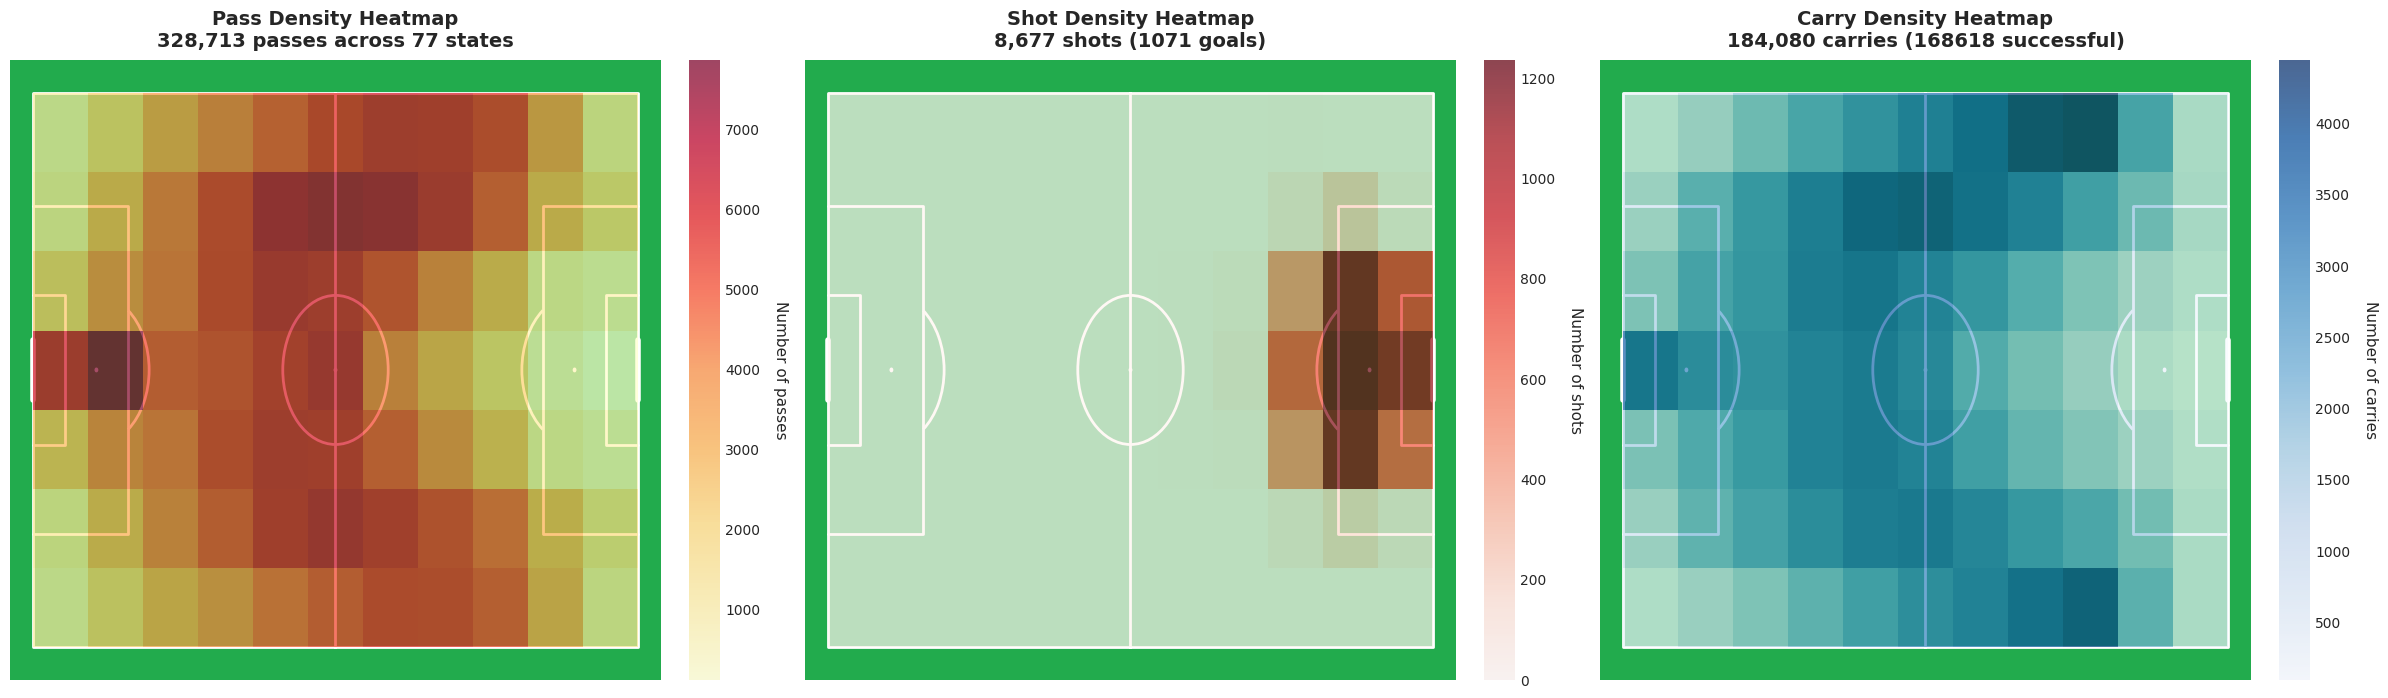


✓ Heatmaps created for passes, shots, and carries

Pass density statistics:
  Hottest states: [34, 60, 61, 59, 16]
  Pass counts: [7859, 7161, 7011, 6868, 6617]
  Total passes: 328,713

Shot density statistics:
  Hottest states: [42, 53, 31, 43, 54]
  Shot counts: [1235, 1176, 1171, 1115, 793]
  Total shots: 8,677
  Goals: 1071

Carry density statistics:
  Hottest states: [74, 73, 60, 8, 59]
  Carry counts: [4441, 4301, 4101, 4079, 3993]
  Total carries: 184,080
  Successful: 168618


In [20]:
# Visualize state coverage - separate heatmaps for passes, shots, and carries
from mplsoccer import Pitch

print("=" * 70)
print("STATE COVERAGE VISUALIZATION")
print("=" * 70)

# Separate passes, shots, and carries
passes_only = actions[actions['action_type'] == 'pass']
shots_only = actions[actions['action_type'] == 'shoot']
carries_only = actions[actions['action_type'] == 'carry']

# Count actions originating from each state
pass_density = passes_only.groupby('state_from').size()
shot_density = shots_only.groupby('state_from').size()
carry_density = carries_only.groupby('state_from').size()

# Create 2D arrays for visualization
pass_grid = np.zeros((grid.n_rows, grid.n_cols))
shot_grid = np.zeros((grid.n_rows, grid.n_cols))
carry_grid = np.zeros((grid.n_rows, grid.n_cols))

for state in range(grid.n_states):
    row = state // grid.n_cols
    col = state % grid.n_cols
    pass_grid[row, col] = pass_density.get(state, 0)
    shot_grid[row, col] = shot_density.get(state, 0)
    carry_grid[row, col] = carry_density.get(state, 0)

# Create pitch objects
pitch = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_color='white',
    pitch_color='#22ab4d',
    linewidth=2
)

# Plot all three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# === PASSES HEATMAP ===
pitch.draw(ax=axes[0])
im1 = axes[0].imshow(
    pass_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='YlOrRd',
    alpha=0.7,
    zorder=2
)
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Number of passes', rotation=270, labelpad=20, fontsize=11)
axes[0].set_title(f'Pass Density Heatmap\n{len(passes_only):,} passes across {grid.n_states} states', 
                  fontsize=14, fontweight='bold', pad=10)

# === SHOTS HEATMAP ===
pitch.draw(ax=axes[1])
im2 = axes[1].imshow(
    shot_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='Reds',
    alpha=0.7,
    zorder=2
)
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('Number of shots', rotation=270, labelpad=20, fontsize=11)
axes[1].set_title(f'Shot Density Heatmap\n{len(shots_only):,} shots ({shots_only["success"].sum()} goals)', 
                  fontsize=14, fontweight='bold', pad=10)

# === CARRIES HEATMAP ===
pitch.draw(ax=axes[2])
im3 = axes[2].imshow(
    carry_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='Blues',
    alpha=0.7,
    zorder=2
)
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cbar3.set_label('Number of carries', rotation=270, labelpad=20, fontsize=11)
axes[2].set_title(f'Carry Density Heatmap\n{len(carries_only):,} carries ({carries_only["success"].sum()} successful)', 
                  fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n✓ Heatmaps created for passes, shots, and carries")
print(f"\nPass density statistics:")
print(f"  Hottest states: {pass_density.nlargest(5).index.tolist()}")
print(f"  Pass counts: {pass_density.nlargest(5).values.tolist()}")
print(f"  Total passes: {len(passes_only):,}")

print(f"\nShot density statistics:")
print(f"  Hottest states: {shot_density.nlargest(5).index.tolist()}")
print(f"  Shot counts: {shot_density.nlargest(5).values.tolist()}")
print(f"  Total shots: {len(shots_only):,}")
print(f"  Goals: {shots_only['success'].sum()}")

print(f"\nCarry density statistics:")
print(f"  Hottest states: {carry_density.nlargest(5).index.tolist()}")
print(f"  Carry counts: {carry_density.nlargest(5).values.tolist()}")
print(f"  Total carries: {len(carries_only):,}")
print(f"  Successful: {carries_only['success'].sum()}")

### 3.2 Spatial Coverage Visualization

Visualize where different actions occur on the pitch.

In [21]:
# Action distribution by field zone
print("=" * 70)
print("ACTION DISTRIBUTION BY FIELD ZONE")
print("=" * 70)

# Define zones based on x-coordinate (columns)
def get_zone_from_state(state, grid):
    """Classify state into defensive/middle/attacking third."""
    col = state % grid.n_cols
    if col < grid.n_cols / 3:
        return 'defensive'
    elif col < 2 * grid.n_cols / 3:
        return 'middle'
    else:
        return 'attacking'

actions['zone_from'] = actions['state_from'].apply(lambda s: get_zone_from_state(s, grid))

# Action distribution by zone
zone_action_dist = actions.groupby(['zone_from', 'action']).size().unstack(fill_value=0)
zone_action_pct = zone_action_dist.div(zone_action_dist.sum(axis=1), axis=0) * 100

print("\nAction distribution by zone (%):")
print("-" * 70)
for zone in ['defensive', 'middle', 'attacking']:
    print(f"\n{zone.upper()} THIRD:")
    if zone in zone_action_pct.index:
        for action_id in sorted(zone_action_pct.columns):
            action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
            pct = zone_action_pct.loc[zone, action_id]
            count = zone_action_dist.loc[zone, action_id]
            if count > 0:
                print(f"  {action_name:20s}: {pct:5.2f}% ({count:6,} actions)")

# Success rate by zone and action
zone_action_success = actions.groupby(['zone_from', 'action'])['success'].mean() * 100
print("\n" + "=" * 70)
print("SUCCESS RATES BY ZONE AND ACTION (%)")
print("=" * 70)
for zone in ['defensive', 'middle', 'attacking']:
    print(f"\n{zone.upper()} THIRD:")
    if zone in zone_action_dist.index:
        for action_id in sorted(zone_action_dist.loc[zone][zone_action_dist.loc[zone] > 0].index):
            action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
            success = zone_action_success.loc[(zone, action_id)]
            print(f"  {action_name:20s}: {success:5.1f}%")

ACTION DISTRIBUTION BY FIELD ZONE

Action distribution by zone (%):
----------------------------------------------------------------------

DEFENSIVE THIRD:
  short_backward      : 11.22% (19,584 actions)
  short_lateral       : 25.19% (43,975 actions)
  short_forward       : 12.02% (20,991 actions)
  long_backward       :  5.43% ( 9,483 actions)
  long_lateral        :  5.07% ( 8,856 actions)
  long_forward        :  5.09% ( 8,889 actions)
  shoot               :  0.00% (     1 actions)
  carry               : 35.97% (62,806 actions)

MIDDLE THIRD:
  short_backward      : 12.17% (30,773 actions)
  short_lateral       : 29.76% (75,246 actions)
  short_forward       : 13.59% (34,359 actions)
  long_backward       :  2.05% ( 5,185 actions)
  long_lateral        :  4.99% (12,623 actions)
  long_forward        :  1.74% ( 4,397 actions)
  shoot               :  0.06% (   162 actions)
  carry               : 35.64% (90,109 actions)

ATTACKING THIRD:
  short_backward      : 12.97% (12,197 act

### 4.6 Action Distribution by Field Zone

### 3.3 Action Distribution by Field Zone

Analyze how action selection varies across defensive/middle/attacking thirds.

### 3.4 Save Encoded Data

Save the state-action encoded dataset for MDP construction.

### 4.1 Load Pre-Built Team MDPs

All 20 Premier League team MDPs have been pre-built using `build_all_team_mdps.py`. Let's load the metadata and verify the MDP structure.eam using the state-action encoded data.

### MDP Components

For each team, we construct:

1. **Transition Matrix P(s' | s, a)**: Probability of reaching state s' when taking action a from state s
   - Shape: (80, 8, 80) where 80 = 77 field states + 3 absorbing states
   - Includes Laplace smoothing (α=2.0) to handle sparse data
   
2. **Policy Matrix π(a | s)**: Observed action selection probabilities per state
   - Shape: (77, 8)
   - Reflects team's actual tactical decisions
   
3. **Reward Function R(s)**: Binary reward for scoring goals
   - Shape: (80,)
   - R(goal_state) = 1.0, all others = 0.0

### Pre-Built MDPs

All 20 Premier League team MDPs have been pre-built and saved to `data/team_mdps/`:
- `P_<team_id>_<team_name>.npy`: Transition matrices
- `pi_<team_id>_<team_name>.npy`: Policy matrices  
- `R_<team_id>_<team_name>.npy`: Reward vectors

This allows fast loading without re-computation.

### 4.1 Load Pre-Built Team MDPs

Load metadata and statistics for all team MDPs.

In [23]:
# Load MDP metadata and statistics
mdp_dir = Path('data/team_mdps')
stats_df = pd.read_csv(mdp_dir / 'team_mdp_statistics.csv')

print("=" * 70)
print("TEAM MDP SUMMARY")
print("=" * 70)
print(f"\nTotal teams: {len(stats_df)}")
print(f"MDP directory: {mdp_dir}")

print("\n" + "=" * 70)
print("Top 5 Teams by Data Volume")
print("=" * 70)
print(stats_df.nlargest(5, 'n_observations')[['team_name', 'n_observations', 'state_action_coverage', 'avg_policy_entropy']])

print("\n" + "=" * 70)
print("Overall Statistics")
print("=" * 70)
print(f"  Mean observations per team: {stats_df['n_observations'].mean():.0f}")
print(f"  Mean state-action coverage: {stats_df['state_action_coverage'].mean():.1%}")
print(f"  Mean policy entropy: {stats_df['avg_policy_entropy'].mean():.3f}")

print("\n✅ All 20 team MDPs available for analysis")

TEAM MDP SUMMARY

Total teams: 20
MDP directory: data/team_mdps

Top 5 Teams by Data Volume
         team_name  n_observations  state_action_coverage  avg_policy_entropy
0  Manchester City           36321               0.863636            1.447371
1        Liverpool           31305               0.860390            1.492423
2          Chelsea           30070               0.853896            1.485117
3          Arsenal           29935               0.852273            1.449643
4     Manchester U           28799               0.853896            1.493152

Overall Statistics
  Mean observations per team: 26074
  Mean state-action coverage: 85.0%
  Mean policy entropy: 1.496

✅ All 20 team MDPs available for analysis


### 4.2 Load Example Team MDP (Manchester City)

Load and validate one team's MDP as an example.

In [25]:
# Load Manchester City's MDP (team_id=40)
test_team_id = 40
city_mdp = mdp.load_team_mdp(test_team_id, mdp_dir)

print("=" * 70)
print(f"LOADED MDP: {city_mdp['team_name']}")
print("=" * 70)
print(f"\nDataset info:")
print(f"  Team ID: {test_team_id}")
print(f"  Actions in dataset: {city_mdp['n_actions']:,}")

print(f"\nMDP Components:")
print(f"  Transition matrix P: {city_mdp['P'].shape}")
print(f"    → (80 states × 8 actions × 80 states)")
print(f"    → 77 field states + 3 absorbing (goal, no_goal, loss)")
print(f"  Policy matrix π: {city_mdp['pi'].shape}")
print(f"    → (77 field states × 8 actions)")
print(f"  Reward vector R: {city_mdp['R'].shape}")
print(f"    → (80 total states)")

# Extract components for easy access
P_city = city_mdp['P']
pi_city = city_mdp['pi']
R_city = city_mdp['R']

# Validate MDP properties
print(f"\nValidation:")
print(f"  ✓ All P ∈ [0,1]: {np.all(P_city >= 0) and np.all(P_city <= 1)}")
print(f"  ✓ All π ∈ [0,1]: {np.all(pi_city >= 0) and np.all(pi_city <= 1)}")
print(f"  ✓ P rows sum to ≈1: {np.allclose(P_city[:77].sum(axis=2).max(), 1.0, atol=1e-5)}")
print(f"  ✓ π rows sum to ≈1: {np.allclose(pi_city.sum(axis=1).max(), 1.0, atol=1e-5)}")

print(f"\nRewards:")
print(f"  Goal state (77): {R_city[77]}")
print(f"  No goal state (78): {R_city[78]}")
print(f"  Loss state (79): {R_city[79]}")
print(f"  Field states: {np.unique(R_city[:77])}")

print("\n✅ MDP validated successfully!")

LOADED MDP: Manchester City

Dataset info:
  Team ID: 40
  Actions in dataset: 36,321

MDP Components:
  Transition matrix P: (80, 8, 80)
    → (80 states × 8 actions × 80 states)
    → 77 field states + 3 absorbing (goal, no_goal, loss)
  Policy matrix π: (77, 8)
    → (77 field states × 8 actions)
  Reward vector R: (80,)
    → (80 total states)

Validation:
  ✓ All P ∈ [0,1]: True
  ✓ All π ∈ [0,1]: True
  ✓ P rows sum to ≈1: True
  ✓ π rows sum to ≈1: True

Rewards:
  Goal state (77): 1.0
  No goal state (78): 0.0
  Loss state (79): 0.0
  Field states: [0.]

✅ MDP validated successfully!


### 4.3 Visualize Team Policy Differences

Compare action selection policies across different teams.

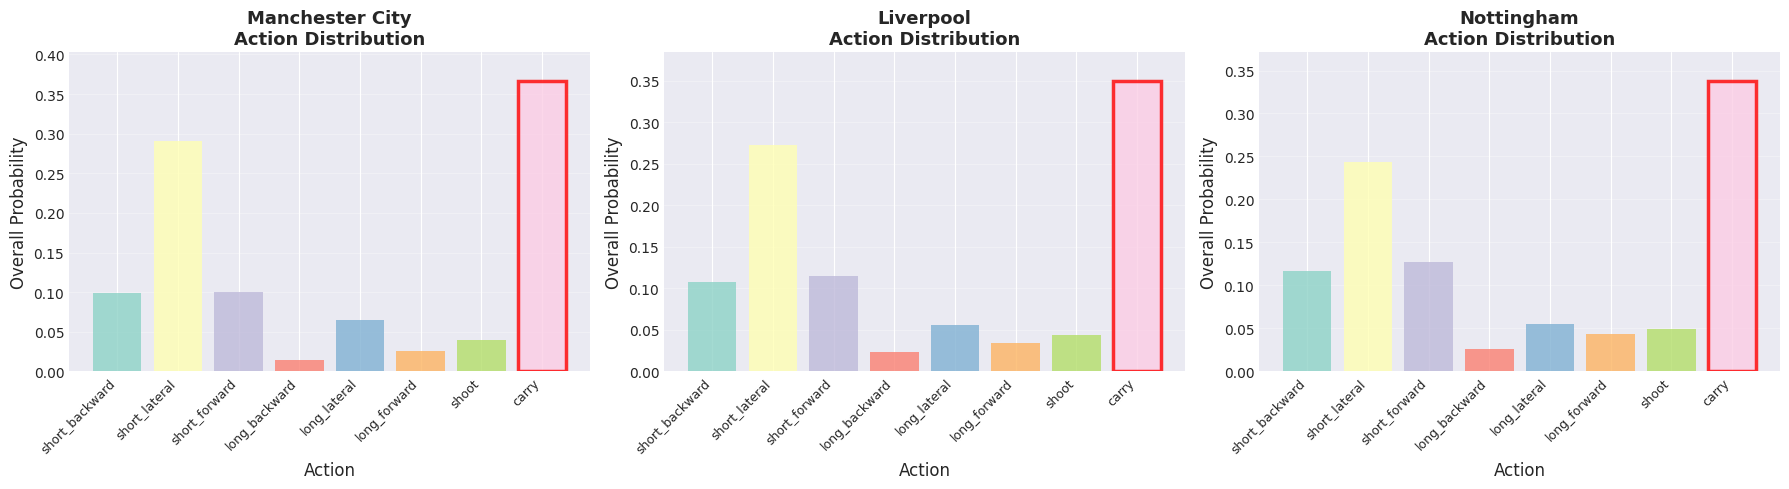

ACTION PREFERENCES BY TEAM

Manchester City:
  Most used: carry (36.6%)
  2nd: short_lateral (29.0%)
  3rd: short_forward (10.0%)

Liverpool:
  Most used: carry (34.9%)
  2nd: short_lateral (27.3%)
  3rd: short_forward (11.5%)

Nottingham:
  Most used: carry (33.8%)
  2nd: short_lateral (24.4%)
  3rd: short_forward (12.7%)


In [26]:
# Compare action preferences across different team styles
# Man City (possession), Liverpool (pressing), Nottingham (direct)
teams_to_compare = {
    40: 'Manchester City',
    2: 'Liverpool', 
    747: 'Nottingham'
}

# Load MDPs for comparison
team_mdps = {tid: mdp.load_team_mdp(tid, mdp_dir) for tid in teams_to_compare.keys()}

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (team_id, team_name) in enumerate(teams_to_compare.items()):
    pi = team_mdps[team_id]['pi']
    
    # Aggregate action probabilities across all states (weighted by state usage)
    action_usage = pi.sum(axis=0) / pi.sum()
    
    ax = axes[idx]
    bars = ax.bar(range(8), action_usage, color=plt.cm.Set3(range(8)), alpha=0.8)
    ax.set_xlabel('Action', fontsize=12)
    ax.set_ylabel('Overall Probability', fontsize=12)
    ax.set_title(f'{team_name}\nAction Distribution', fontsize=13, fontweight='bold')
    ax.set_xticks(range(8))
    ax.set_xticklabels([sa.ACTION_NAMES[i] for i in range(8)], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(action_usage) * 1.1)
    
    # Highlight most used action
    max_idx = np.argmax(action_usage)
    bars[max_idx].set_edgecolor('red')
    bars[max_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('outputs/figures/team_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=" * 70)
print("ACTION PREFERENCES BY TEAM")
print("=" * 70)
for team_id, team_name in teams_to_compare.items():
    pi = team_mdps[team_id]['pi']
    action_usage = pi.sum(axis=0) / pi.sum()
    top_3_indices = np.argsort(action_usage)[-3:][::-1]
    
    print(f"\n{team_name}:")
    print(f"  Most used: {sa.ACTION_NAMES[top_3_indices[0]]} ({action_usage[top_3_indices[0]]:.1%})")
    print(f"  2nd: {sa.ACTION_NAMES[top_3_indices[1]]} ({action_usage[top_3_indices[1]]:.1%})")
    print(f"  3rd: {sa.ACTION_NAMES[top_3_indices[2]]} ({action_usage[top_3_indices[2]]:.1%})")

### 4.4 Spatial Policy Heatmap (Manchester City)

Visualize where Man City prefers different actions across the pitch.

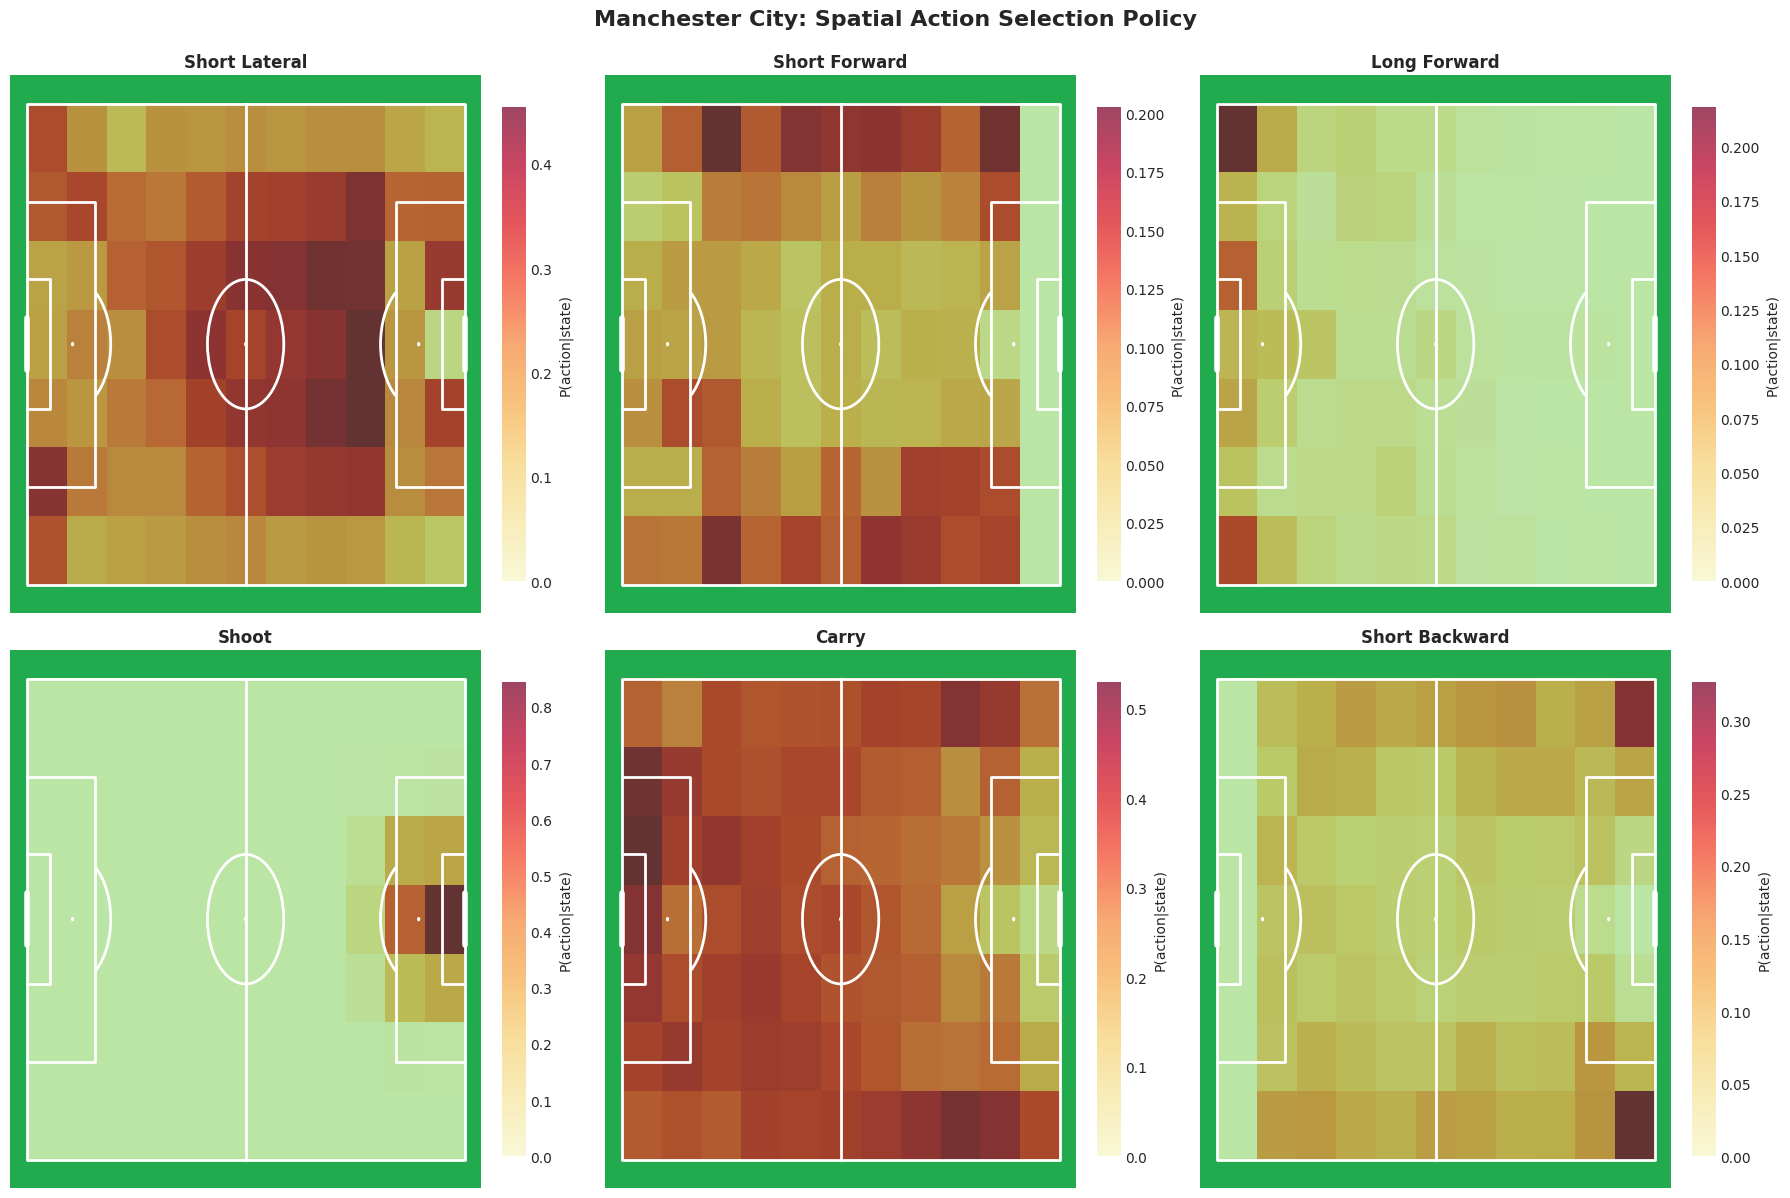

✅ Spatial policy visualization complete


In [28]:
# Visualize Manchester City's spatial action preferences
# Show heatmaps for the 6 most interesting actions

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Select 6 key actions to visualize
actions_to_plot = [
    1,  # short_lateral
    2,  # short_forward
    5,  # long_forward
    6,  # shoot
    7,  # carry
    0   # short_backward
]

for idx, action_id in enumerate(actions_to_plot):
    ax = axes[idx]
    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                 pitch_color='#22ab4e', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Get policy for this action across all states
    policy_action = pi_city[:, action_id]
    
    # Reshape to grid (7 rows × 11 cols)
    policy_grid = np.zeros((grid.n_rows, grid.n_cols))
    for state in range(grid.n_states):
        # Decode state to grid coordinates
        # State encoding: row * n_cols + col
        col = state % grid.n_cols
        row = state // grid.n_cols
        policy_grid[row, col] = policy_action[state]
    
    # Plot heatmap on pitch (flip vertically for correct orientation)
    extent = [0, 105, 0, 68]
    im = ax.imshow(np.flipud(policy_grid), extent=extent, origin='lower', 
                   cmap='YlOrRd', alpha=0.7, aspect='auto', 
                   vmin=0, vmax=policy_action.max())
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('P(action|state)', fontsize=10)
    
    # Title
    action_name = sa.ACTION_NAMES[action_id].replace('_', ' ').title()
    ax.set_title(f'{action_name}', fontsize=12, fontweight='bold')

plt.suptitle('Manchester City: Spatial Action Selection Policy', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('outputs/figures/man_city_spatial_policy.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Spatial policy visualization complete")

### 4.5 Shooting Success Analysis

Analyze the transition probabilities for shooting to understand position-based expected goals.

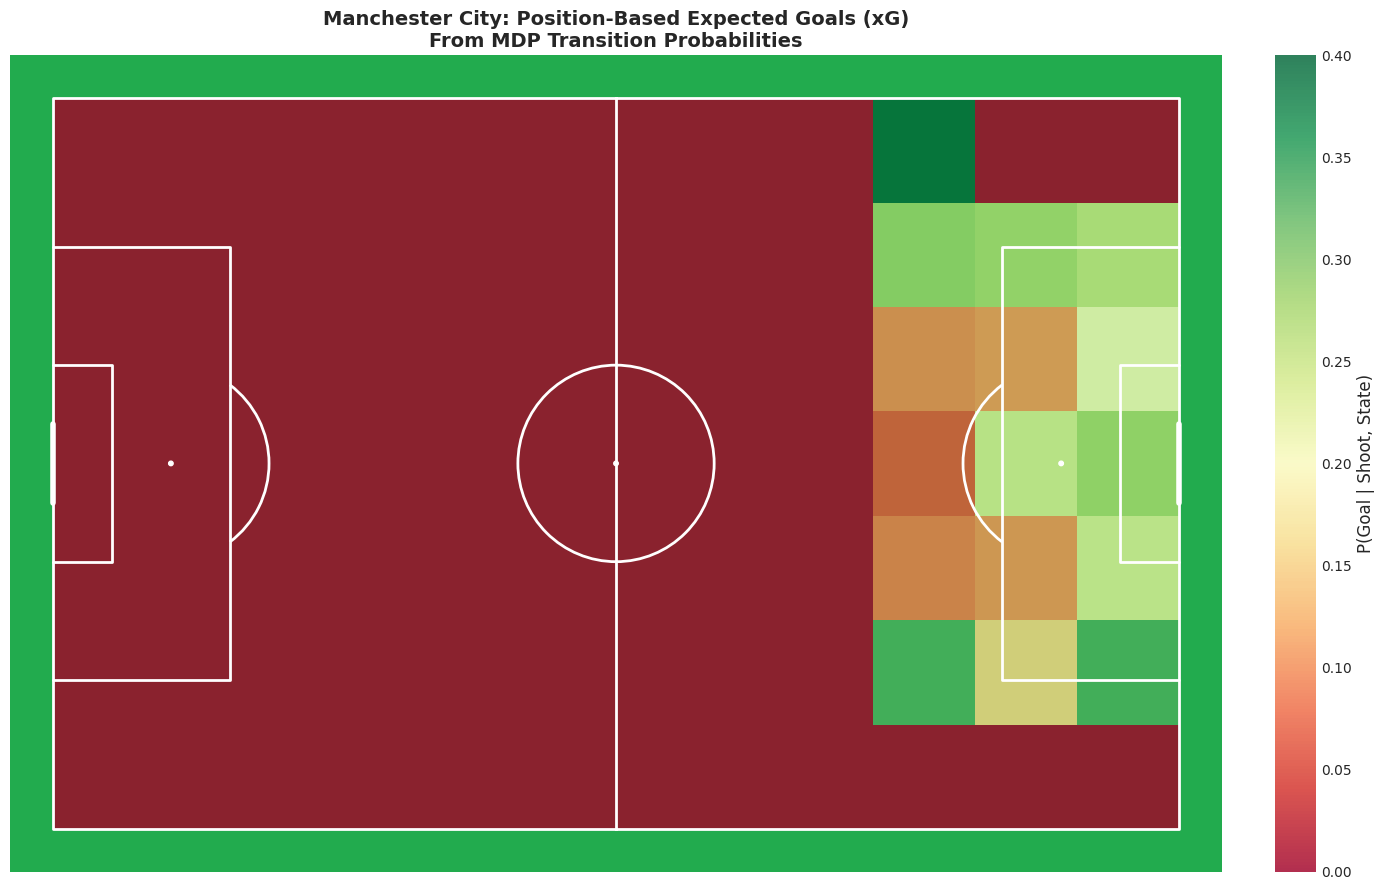

SHOOTING SUCCESS ANALYSIS

Goal probability when shooting:
  Mean (all states with shots): 0.215
  Median: 0.232
  Max: 0.400
  Min (non-zero): 0.062

States where shooting occurred: 16 / 77
Coverage: 20.8%

✅ Position-based xG analysis complete


In [29]:
# Analyze shooting success probability by field position
goal_state = 77  # Absorbing state for successful shots
shoot_action = 6  # Shoot action

# Extract P(goal | shoot, state) from transition matrix
shoot_success = P_city[:77, shoot_action, goal_state]

# Reshape to grid for visualization
shoot_grid = np.zeros((grid.n_rows, grid.n_cols))
for state in range(grid.n_states):
    # Decode state to grid coordinates
    # State encoding: row * n_cols + col
    col = state % grid.n_cols
    row = state // grid.n_cols
    shoot_grid[row, col] = shoot_success[state]

# Visualize on pitch
fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
             pitch_color='#22ab4e', line_color='white', linewidth=2)
pitch.draw(ax=ax)

# Plot heatmap (flip vertically for correct orientation)
im = ax.imshow(np.flipud(shoot_grid), extent=[0, 105, 0, 68], origin='lower',
              cmap='RdYlGn', alpha=0.8, aspect='auto', vmin=0, vmax=shoot_success.max())

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('P(Goal | Shoot, State)', fontsize=12)

ax.set_title('Manchester City: Position-Based Expected Goals (xG)\nFrom MDP Transition Probabilities',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/man_city_shooting_success.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("=" * 70)
print("SHOOTING SUCCESS ANALYSIS")
print("=" * 70)
nonzero_shoot = shoot_success[shoot_success > 0]
print(f"\nGoal probability when shooting:")
print(f"  Mean (all states with shots): {nonzero_shoot.mean():.3f}")
print(f"  Median: {np.median(nonzero_shoot):.3f}")
print(f"  Max: {shoot_success.max():.3f}")
print(f"  Min (non-zero): {nonzero_shoot.min():.3f}")
print(f"\nStates where shooting occurred: {len(nonzero_shoot)} / {grid.n_states}")
print(f"Coverage: {len(nonzero_shoot) / grid.n_states:.1%}")

print("\n✅ Position-based xG analysis complete")

### 4.6 Summary: MDP Analysis

Key findings from MDP structure analysis.

In [30]:
print("=" * 70)
print("SECTION 4 SUMMARY: MDP CONSTRUCTION & ANALYSIS")
print("=" * 70)

print("\n✅ Completed Tasks:")
print("  1. Loaded all 20 team MDPs from pre-built files")
print("  2. Validated MDP structure (P, π, R matrices)")
print("  3. Compared action preferences across teams")
print("  4. Visualized spatial policy distributions")
print("  5. Analyzed position-based shooting success (xG)")

print("\n📊 Key Insights:")
print(f"  • Average state-action coverage: {stats_df['state_action_coverage'].mean():.1%}")
print(f"  • Grid resolution: 7 rows × 11 cols = 77 field states")
print(f"  • Action space: 8 actions (6 passes + shoot + carry)")
print(f"  • Teams show distinct tactical profiles in action selection")

print("\n➡️  Next Steps:")
print("  • Section 5: Expected goals using fundamental matrix")
print("  • Section 6: Counterfactual policy analysis")
print("  • Section 7: Quality-quantity trade-off curves")

print("\n" + "=" * 70)

SECTION 4 SUMMARY: MDP CONSTRUCTION & ANALYSIS

✅ Completed Tasks:
  1. Loaded all 20 team MDPs from pre-built files
  2. Validated MDP structure (P, π, R matrices)
  3. Compared action preferences across teams
  4. Visualized spatial policy distributions
  5. Analyzed position-based shooting success (xG)

📊 Key Insights:
  • Average state-action coverage: 85.0%
  • Grid resolution: 7 rows × 11 cols = 77 field states
  • Action space: 8 actions (6 passes + shoot + carry)
  • Teams show distinct tactical profiles in action selection

➡️  Next Steps:
  • Section 5: Expected goals using fundamental matrix
  • Section 6: Counterfactual policy analysis
  • Section 7: Quality-quantity trade-off curves



## 5. Expected Goals Using Fundamental Matrix

Compute expected goals under current team policies using the fundamental matrix N = (I - Q)^(-1), where Q is the transient sub-matrix.

## 6. Counterfactual Analysis - Policy Modifications

Evaluate "what-if" scenarios by modifying team policies and computing expected goal changes.

## 7. Quality-Quantity Trade-off Analysis

Visualize how increasing action frequency affects success rates and expected goals (Van Roy Method 3).

In [31]:
# TODO: Compute quality distributions
# quality_dist = sm.compute_quality_distributions(passes, quality_metric='outcome')

# print(f"✓ Computed quality distributions for {len(quality_dist)} (state, action) pairs")

# # Example: visualize one distribution
# example_state, example_action = 100, 0  # State 100, short_forward
# sm.plot_quality_distribution(passes, example_state, example_action)

print("📝 NOTE: Quality distribution analysis to be implemented")

📝 NOTE: Quality distribution analysis to be implemented


In [32]:
# TODO: Compute fundamental matrix
# N = an.compute_fundamental_matrix(P, pi)
# print(f"✓ Fundamental matrix computed: shape {N.shape}")

# # Compute baseline expected goals
# possession_starts = passes.groupby('state_from').size().reindex(range(n_states), fill_value=0).values
# eg_baseline = an.expected_goals_total(N, pi, P, R, possession_starts)

# print(f"\nBaseline Expected Goals: {eg_baseline:.2f}")
# print(f"Actual goals in data: [TO BE COMPUTED]")

print("📝 NOTE: Fundamental matrix computation to be implemented")

📝 NOTE: Fundamental matrix computation to be implemented


In [33]:
# TODO: Compute optimal actions
# optimal_actions = an.optimal_action_per_state(N, pi, P, R, n_actions)

# # Visualize
# viz.plot_optimal_actions_heatmap(
#     optimal_actions, 
#     grid, 
#     sa.ACTION_NAMES,
#     save_path='outputs/figures/optimal_actions_heatmap.png'
# )

print("📝 NOTE: Optimal action analysis to be implemented")

📝 NOTE: Optimal action analysis to be implemented


## 9. Counterfactual Analysis - Policy Modifications

Test "what-if" scenarios: changing pass policies in specific zones.

In [34]:
# TODO: Define counterfactual scenarios
# scenarios = {
#     'baseline': {},
#     'more_long_forward_defensive': {
#         (s, 6): 0.20 for s in range(0, 100)  # +20% long_forward in defensive third
#     },
#     'more_medium_forward_midfield': {
#         (s, 3): 0.15 for s in range(100, 250)  # +15% medium_forward in midfield
#     },
#     'less_long_lateral': {
#         (s, 7): -0.10 for s in range(0, n_states)  # -10% long_lateral everywhere
#     }
# }

# # Run counterfactual analysis
# results = an.counterfactual_analysis(
#     pi, P, R, possession_starts, scenarios, quality_distributions=quality_dist
# )

# print(results)

# # Visualize results
# viz.plot_counterfactual_results(results, save_path='outputs/figures/counterfactual_results.png')

print("📝 NOTE: Counterfactual analysis to be implemented")

📝 NOTE: Counterfactual analysis to be implemented


## 10. Quality-Quantity Trade-off Curves

Explore how expected goals change with varying frequency changes for specific pass types.

In [35]:
# TODO: Generate trade-off curves
# # Example: long_forward passes in central midfield
# target_states = range(150, 200)  # Central midfield zones
# target_action = 6  # long_forward

# freq_changes = np.linspace(-30, 50, 17)  # -30% to +50%
# eg_values = []

# for change in freq_changes:
#     modifications = {(s, target_action): change/100 for s in target_states}
#     pi_mod = an.modify_policy(pi, modifications)
#     P_mod = sm.modify_transition_matrix(P, quality_dist, modifications)
#     N_mod = an.compute_fundamental_matrix(P_mod, pi_mod)
#     eg = an.expected_goals_total(N_mod, pi_mod, P_mod, R, possession_starts)
#     eg_values.append(eg)

# viz.plot_quality_quantity_tradeoff(
#     freq_changes, 
#     eg_values, 
#     eg_baseline,
#     title="Long Forward Passes in Midfield: Quality-Quantity Trade-off",
#     save_path='outputs/figures/tradeoff_curve.png'
# )

print("📝 NOTE: Trade-off curve analysis to be implemented")

📝 NOTE: Trade-off curve analysis to be implemented
